In [1]:
# !pip install easyocr
# !pip install scipy==1.11.2
!python3 -m pip install paddlepaddle-gpu==3.2.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu126/
!python3 -m pip install paddleocr

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu126/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 GB 846.1 kB/s eta 0:00:000:0100:04
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.8/485.8 kB 9.7 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 11.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 11.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 12.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.4 MB/s eta 0:00:0000:0100:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 3.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 5.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 6.7 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [55]:
import polars as pl
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm
import os
import cv2

In [ ]:
IMG_DIR = '/home/dangnh36/datasets/ecg/raw/train/'
ALL_LEADS = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
LEAD_TO_SIG_LEN = {
    'I': (0, 1/4), 'II': (0, 1.0), 'III': (0, 1/4), 'aVR': (1/4, 2/4),
    'aVL': (1/4, 2/4), 'aVF': (1/4, 2/4), 'V1': (2/4, 3/4), 'V2': (2/4, 3/4),
    'V3': (2/4, 3/4), 'V4': (3/4, 1), 'V5': (3/4, 1), 'V6': (3/4, 1)
}
print({k: v[1] - v[0] for k, v in LEAD_TO_SIG_LEN.items()})

{'I': 0.25, 'II': 1.0, 'III': 0.25, 'aVR': 0.25, 'aVL': 0.25, 'aVF': 0.25, 'V1': 0.25, 'V2': 0.25, 'V3': 0.25, 'V4': 0.25, 'V5': 0.25, 'V6': 0.25}


In [ ]:
df = pl.read_csv('/home/dangnh36/datasets/ecg/raw/train.csv')
df

id,fs,sig_len
i64,i64,i64
7663343,500,5000
10140238,1000,10000
11842146,1000,10000
19030958,250,2500
19585145,512,5120
…,…,…
4277555223,1000,10000
4283871417,256,2560
4284351157,512,5120


In [58]:
((df['fs'] * 10)  == df['sig_len']).all()

True

In [65]:
df.group_by('fs').agg(
    pl.len(),
    (pl.col('fs').first() * 2.5).alias('len_2dot5'),
    pl.col('sig_len').first().alias('len_10')
).sort('fs')

fs,len,len_2dot5,len_10
i64,u32,f64,i64
250,163,625.0,2500
256,163,640.0,2560
500,163,1250.0,5000
512,163,1280.0,5120
1000,163,2500.0,10000
1025,162,2562.5,10250


In [7]:
from paddleocr import PaddleOCR


# ch, en, fr, de, japan, korean, chinese_cht, af, it, es,
# bs, pt, cs, cy, da, et, ga, hr, hu, rslatin, id, oc, is,
# lt, mi, ms, nl, no, pl, sk, sl, sq, sv, sw, tl, tr, uz, la, ru, be, uk
pipeline = PaddleOCR(
    lang = None,
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    # text_detection_model_name = 'PP-OCRv5_server_det',
    text_det_thresh = 0.1,
    text_det_box_thresh = 0.1,
    text_det_unclip_ratio = None,
    text_det_input_shape = None,
    text_det_limit_side_len = 1024,
    text_det_limit_type = 'min',
    text_rec_score_thresh = 0.05,
    text_rec_input_shape = None,
    device = 'gpu:0',
    enable_hpi = False,
    use_tensorrt = False,
    precision='fp32',
)

Creating model: ('PP-OCRv5_server_det', None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

inference.yml:   0%|          | 0.00/903 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

inference.json: 0.00B [00:00, ?B/s]

...

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

inference.pdiparams:   0%|          | 0.00/84.4M [00:00<?, ?B/s]

inference.json: 0.00B [00:00, ?B/s]

In [8]:
all_shapes = []
all_sig_stats = []
all_ocr_results = []

for row_idx, row in tqdm(enumerate(df.iter_rows(named = True)), total = len(df)):
    sid = row['id']
    sid_dir = os.path.join(IMG_DIR, str(sid))
    names = sorted(os.listdir(sid_dir))
    assert len(names) == 10
    sid_shapes = []
    for idx in [1, 3, 4, 5, 6, 9, 10, 11, 12]:
        img_path = os.path.join(sid_dir, f'{sid}-{idx:04d}.png')
        
        # print(img_path)
        img = cv2.imread(img_path)
        assert img.dtype == np.uint8
        assert img.shape[2] == 3
        sid_shapes.append(img.shape[:2])

        # perform easy OCR
        if idx == 1:
            ocr_result = pipeline.predict(img)
            # plt.imshow(img)
            # plt.show()
            # print(ocr_result)
            assert len(ocr_result) == 1
            ocr_result = ocr_result[0]
            ocr_text = ocr_result['rec_texts']
            all_ocr_results.append(ocr_text)
            print(row_idx, sid, img.shape, img.min(), img.max(), ocr_text)
            
    all_shapes.append(sid_shapes)

    ecg_df = pl.scan_csv(os.path.join(sid_dir, f'{sid}.csv')).select(pl.col('*').cast(pl.Float64)).collect()
    # display(ecg_df)
    signal = ecg_df.to_numpy()
    null_mask = ~np.isnan(signal)
    lead_segments = {}
    sig_len = len(ecg_df)
    assert sig_len == row['sig_len']
    sid_sig_stats = {}
    for lead_idx, lead_name in enumerate(ecg_df.columns):
        assert lead_name in LEAD_TO_SIG_LEN
        idx = null_mask[:, lead_idx].nonzero()[0]
        first = int(idx[0]) if len(idx) > 0 else None
        last = int(idx[-1]) if len(idx) > 0 else None
        expect_start = int(LEAD_TO_SIG_LEN[lead_name][0] * sig_len)
        expect_end = int(LEAD_TO_SIG_LEN[lead_name][1] * sig_len - 1)
        assert first == expect_start and last == expect_end
        lead_segments[lead_name] = (first, last)

        lead_sig = signal[first:last, lead_idx]
        sig_stats = {
            'min': np.min(lead_sig),
            'max': np.max(lead_sig),
            'mean': np.min(lead_sig),
            'median': np.median(lead_sig),
            'std': np.std(lead_sig)
        }
        sid_sig_stats[lead_name] = sig_stats
    all_sig_stats.append(sid_sig_stats)

  0%|          | 0/977 [00:00<?, ?it/s]

0 7663343 (1700, 2200, 3) 0 255 ['L', '2', 'V', '.', ',', '-', 'I', '1', '一', '一', '7', '-', '三', '2', '国', '|', 'i', 'T', '+', '+', '二', '一', 'T', '-', '+', 'A', "'", '袤', '1', '2', 'X', 'A', '1', 'T', 'aVF', 'V6', '中', '25mm/s', '10mm/mV']


  0%|          | 1/977 [00:04<1:10:21,  4.33s/it]

1 10140238 (1700, 2200, 3) 0 255 ['+', '！', '2', '1', 'aVL', 'V2', '-', '+', '-', '.', '`', '中', 'X', '1', '|', '□', '日', ',', '4', '我', 'H', 'F', '-', '+', 'A', '-', '□', '+', '1', '1', '+', '川', 'aVF', 'V3', 'V6', 'X', '25mm/s', '10mm/mV']


  0%|          | 2/977 [00:08<1:06:20,  4.08s/it]

...

100%|█████████▉| 975/977 [1:01:33<00:07,  3.73s/it]

975 4289880010 (1700, 2200, 3) 0 255 ['中', '7', '+', '7', '7', 'X', '出', 'aVL', '！', '！', 'H', '-', '7', 'aVF', 'V3', 'V6', '25mm/s', '10mm/mV']


100%|█████████▉| 976/977 [1:01:37<00:03,  3.81s/it]

976 4292118763 (1700, 2200, 3) 0 255 ['E', 'X', '1', 'X', '.', 'X', 'X', 'aVL', '中', 'F', '，', '1', '-', '/', '/', '/', '/', '广', 'aVF', 'V3', 'V6', '7', '十', '1', '十', 'E', '。', 'E', '。', 'E', '1', '-', '25mm/s', '10mm/mV']


100%|██████████| 977/977 [1:01:40<00:00,  3.79s/it]


In [9]:
len(all_shapes), len(all_sig_stats), len(all_ocr_results)

(977, 977, 977)

In [10]:
all_shapes[0]

[(1700, 2200),
 (1652, 2132),
 (1652, 2136),
 (3024, 4032),
 (4000, 3000),
 (3024, 4032),
 (3024, 4032),
 (1652, 2140),
 (1652, 2140)]

In [14]:
ecg_df.columns

['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

In [23]:
df = df.with_columns(
    **{f'height_{idx:04d}': pl.Series([e[i][0] for e in all_shapes], dtype = pl.Int32) for i, idx in enumerate([1, 3, 4, 5, 6, 9, 10, 11, 12])},
    **{f'width_{idx:04d}': pl.Series([e[i][1] for e in all_shapes], dtype = pl.Int32) for i, idx in enumerate([1, 3, 4, 5, 6, 9, 10, 11, 12])},
    sig_stat = pl.Series([str(e) for e in all_sig_stats]),
    **{
        f'ecg_{lead_name}_{stat}': pl.Series([e[lead_name][stat] for e in all_sig_stats]) \
            for lead_name in ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'] \
                for stat in ['min', 'max', 'mean', 'std', 'median']
    },
    ocr_text = pl.Series([str(e) for e in all_ocr_results], dtype = pl.String)
)
df

id,fs,sig_len,height_0001,height_0003,height_0004,height_0005,height_0006,height_0009,height_0010,height_0011,height_0012,width_0001,width_0003,width_0004,width_0005,width_0006,width_0009,width_0010,width_0011,width_0012,sig_stat,ecg_I_min,ecg_I_max,ecg_I_mean,ecg_I_std,ecg_I_median,ecg_II_min,ecg_II_max,ecg_II_mean,ecg_II_std,ecg_II_median,ecg_III_min,ecg_III_max,ecg_III_mean,ecg_III_std,ecg_III_median,…,ecg_aVL_median,ecg_aVF_min,ecg_aVF_max,ecg_aVF_mean,ecg_aVF_std,ecg_aVF_median,ecg_V1_min,ecg_V1_max,ecg_V1_mean,ecg_V1_std,ecg_V1_median,ecg_V2_min,ecg_V2_max,ecg_V2_mean,ecg_V2_std,ecg_V2_median,ecg_V3_min,ecg_V3_max,ecg_V3_mean,ecg_V3_std,ecg_V3_median,ecg_V4_min,ecg_V4_max,ecg_V4_mean,ecg_V4_std,ecg_V4_median,ecg_V5_min,ecg_V5_max,ecg_V5_mean,ecg_V5_std,ecg_V5_median,ecg_V6_min,ecg_V6_max,ecg_V6_mean,ecg_V6_std,ecg_V6_median,ocr_text
i64,i64,i64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
7663343,500,5000,1700,1652,1652,3024,4000,3024,3024,1652,1652,2200,2132,2136,4032,3000,4032,4032,2140,2140,"""{'I': {'min': -0.15, 'max': 0.…",-0.15,0.552,-0.15,0.107343,-0.037,-0.827,2.325,-0.827,0.188562,-0.025,-0.906,2.187,-0.906,0.325769,0.02,…,-0.019,-0.415,0.2,-0.415,0.079544,-0.008,-1.344,0.19,-1.344,0.201962,0.029,-1.248,0.559,-1.248,0.226103,-0.034,-1.185,1.066,-1.185,0.234512,-0.041,-0.725,1.038,-0.725,0.177482,-0.048,-0.32,0.59,-0.32,0.106767,-0.044,-0.095,0.335,-0.095,0.069024,-0.025,"""['L', '2', 'V', '.', ',', '-',…"
10140238,1000,10000,1700,1652,1652,3024,4000,3024,3024,1652,1652,2200,2128,2132,4032,3000,4032,4032,2130,2138,"""{'I': {'min': -0.409, 'max': 0…",-0.409,0.685,-0.409,0.110914,-0.044,-0.25,0.75,-0.25,0.11655,-0.018,-0.154,0.305,-0.154,0.054798,-0.009,…,-0.025,-0.045,0.425,-0.045,0.0621,0.045,-0.888,0.31,-0.888,0.169706,0.209,-2.356,0.596,-2.356,0.479414,0.034,-2.182,0.516,-2.182,0.400923,0.06,-2.308,0.708,-2.308,0.341297,0.049,-0.599,2.392,-0.599,0.348411,-0.013,-0.194,1.564,-0.194,0.21152,0.0,"""['+', '！', '2', '1', 'aVL', 'V…"
11842146,1000,10000,1700,1652,1652,3024,4000,3024,4032,1652,1652,2200,2126,2132,4032,3000,4032,3024,2150,2149,"""{'I': {'min': -0.333, 'max': 1…",-0.333,1.07,-0.333,0.169261,-0.061,-0.335,0.628,-0.335,0.105833,-0.025,-0.845,0.234,-0.845,0.120818,0.042,…,-0.039,-0.473,0.179,-0.473,0.078854,0.003,-0.963,0.33,-0.963,0.137705,0.028,-0.219,0.388,-0.219,0.106829,-0.045,-0.235,0.528,-0.235,0.141747,-0.055,-0.219,0.984,-0.219,0.174736,-0.069,-0.228,0.851,-0.228,0.129305,-0.04,-0.21,0.735,-0.21,0.108269,-0.034,"""['+', '+', '一', '一', '+', 'H',…"
19030958,250,2500,1700,1652,1652,3024,3000,3024,3024,1652,1652,2200,2130,2132,4032,4000,4032,4032,2152,2150,"""{'I': {'min': -0.175, 'max': 0…",-0.175,0.567,-0.175,0.087593,-0.014,-0.087,0.201,-0.087,0.06052,-0.019,-0.485,0.18,-0.485,0.078593,0.014,…,-0.013,-0.282,0.161,-0.282,0.054697,-0.009,-1.002,0.125,-1.002,0.183252,0.055,-1.77,0.45,-1.77,0.337419,0.025,-1.349,0.476,-1.349,0.26325,-0.0275,-0.931,0.633,-0.931,0.215047,-0.04,-0.32,0.516,-0.32,0.117513,-0.041,-0.085,0.402,-0.085,0.077925,-0.034,"""['—', 'E', '日', '十', '√', '一',…"
19585145,512,5120,1700,1652,1652,3024,3000,3024,3024,1652,1652,2200,2128,2132,4032,4000,4032,4032,2134,2142,"""{'I': {'min': -0.457, 'max': 0…",-0.457,0.614,-0.457,0.142086,-0.018,-0.36,0.58,-0.36,0.11229,-0.029,-0.164,0.589,-0.164,0.082809,0.034,…,-0.031,-0.196,0.283,-0.196,0.046071,-0.023,-0.33,0.215,-0.33,0.046752,0.032,-1.297,0.75,-1.297,0.276427,-0.049,-1.345,0.734,-1.345,0.270506,-0.064,-1.015,0.939,-1.015,0.269628,-0.073,-0.635,1.249,-0.635,0.236478,-0.06,-0.449,1.178,-0.449,0.20605,-0.065,"""['-', ',', ',', ',', '7', '口',…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
4277555223,

In [40]:
all_ocr_detected_leads = []
all_mm_s = []
all_mm_mv = []
for row in df.iter_rows(named = True):
    ocr_text = eval(row['ocr_text'])
    # print(ocr_text, type(ocr_text))
    detected_leads = []
    mm_s = []
    mm_mv = []
    for e in ocr_text:
        if e in ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']:
            detected_leads.append(e)
        if 'mm/s' in e.lower():
            mm_s.append(e)
        if 'mm/mv' in e.lower():
            mm_mv.append(e)

    if len(mm_s) < 1 or len(mm_mv) < 1:
        print('\n---MISS_DETECTION:', row['id'], ocr_text)
        all_mm_s.append(None)
        all_mm_mv.append(None)
    elif len(mm_s) > 1 or len(mm_mv) > 1:
        print('\n+++DUPLICATE:', row['id'], ocr_text)
        all_mm_s.append(None)
        all_mm_mv.append(None)
    else:
        assert len(mm_s) == 1 and len(mm_mv) == 1
        # print(mm_s, mm_mv)
        mm_s_number = float(mm_s[0].lower().replace('mm/s', ''))
        mm_mv_number = float(mm_mv[0].lower().replace('mm/mv', ''))
        all_mm_s.append(mm_s_number)
        all_mm_mv.append(mm_mv_number)
        
    if len(detected_leads) != len(set(detected_leads)):
        from collections import Counter
        c = Counter(detected_leads)
        dups = [e[0] for e in c.most_common() if e[1] > 1]
        print('\n***DUPLICATE_LEADS:', row['id'], [e for e in c.most_common() if e[1] > 1])
        detected_leads = [e for e in detected_leads if e not in dups]
        assert len(detected_leads) == len(set(detected_leads))
    all_ocr_detected_leads.append(detected_leads)


***DUPLICATE_LEADS: 119693645 [('I', 2)]

***DUPLICATE_LEADS: 563193340 [('I', 2)]

***DUPLICATE_LEADS: 873908108 [('I', 2)]

***DUPLICATE_LEADS: 950071314 [('I', 2)]

***DUPLICATE_LEADS: 1094825522 [('I', 2)]

***DUPLICATE_LEADS: 1220748004 [('I', 2)]

***DUPLICATE_LEADS: 1380849732 [('I', 2)]

***DUPLICATE_LEADS: 1441897956 [('I', 2)]

***DUPLICATE_LEADS: 1752267607 [('I', 3)]

***DUPLICATE_LEADS: 1815763003 [('I', 2)]

***DUPLICATE_LEADS: 1893309127 [('I', 2)]

***DUPLICATE_LEADS: 1949321289 [('I', 2)]

***DUPLICATE_LEADS: 2284764486 [('I', 2)]

***DUPLICATE_LEADS: 2457447088 [('I', 2)]

***DUPLICATE_LEADS: 2628830113 [('I', 2)]

***DUPLICATE_LEADS: 2653902906 [('I', 2)]

***DUPLICATE_LEADS: 2711409608 [('I', 2)]

***DUPLICATE_LEADS: 2952613248 [('I', 2)]

***DUPLICATE_LEADS: 3110017734 [('I', 2)]

***DUPLICATE_LEADS: 3123075706 [('I', 2)]

***DUPLICATE_LEADS: 3405310076 [('I', 2)]

***DUPLICATE_LEADS: 3793512560 [('I', 2)]

***DUPLICATE_LEADS: 3893290252 [('I', 2)]

***DUPLICATE_L

In [42]:
df = df.with_columns(
    ocr_num_detected_leads = pl.Series([len(e) for e in all_ocr_detected_leads], dtype = pl.Int32),
    ocr_detected_leads = pl.Series([str(e) for e in all_ocr_detected_leads], dtype = pl.String),
    mm_s = pl.Series(all_mm_s),
    mm_mv = pl.Series(all_mm_mv)
)
df

id,fs,sig_len,height_0001,height_0003,height_0004,height_0005,height_0006,height_0009,height_0010,height_0011,height_0012,width_0001,width_0003,width_0004,width_0005,width_0006,width_0009,width_0010,width_0011,width_0012,sig_stat,ecg_I_min,ecg_I_max,ecg_I_mean,ecg_I_std,ecg_I_median,ecg_II_min,ecg_II_max,ecg_II_mean,ecg_II_std,ecg_II_median,ecg_III_min,ecg_III_max,ecg_III_mean,ecg_III_std,ecg_III_median,…,ecg_aVF_std,ecg_aVF_median,ecg_V1_min,ecg_V1_max,ecg_V1_mean,ecg_V1_std,ecg_V1_median,ecg_V2_min,ecg_V2_max,ecg_V2_mean,ecg_V2_std,ecg_V2_median,ecg_V3_min,ecg_V3_max,ecg_V3_mean,ecg_V3_std,ecg_V3_median,ecg_V4_min,ecg_V4_max,ecg_V4_mean,ecg_V4_std,ecg_V4_median,ecg_V5_min,ecg_V5_max,ecg_V5_mean,ecg_V5_std,ecg_V5_median,ecg_V6_min,ecg_V6_max,ecg_V6_mean,ecg_V6_std,ecg_V6_median,ocr_text,ocr_num_detected_leads,ocr_detected_leads,mm_s,mm_mv
i64,i64,i64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i32,str,f64,f64
7663343,500,5000,1700,1652,1652,3024,4000,3024,3024,1652,1652,2200,2132,2136,4032,3000,4032,4032,2140,2140,"""{'I': {'min': -0.15, 'max': 0.…",-0.15,0.552,-0.15,0.107343,-0.037,-0.827,2.325,-0.827,0.188562,-0.025,-0.906,2.187,-0.906,0.325769,0.02,…,0.079544,-0.008,-1.344,0.19,-1.344,0.201962,0.029,-1.248,0.559,-1.248,0.226103,-0.034,-1.185,1.066,-1.185,0.234512,-0.041,-0.725,1.038,-0.725,0.177482,-0.048,-0.32,0.59,-0.32,0.106767,-0.044,-0.095,0.335,-0.095,0.069024,-0.025,"""['L', '2', 'V', '.', ',', '-',…",3,"""['I', 'aVF', 'V6']""",25.0,10.0
10140238,1000,10000,1700,1652,1652,3024,4000,3024,3024,1652,1652,2200,2128,2132,4032,3000,4032,4032,2130,2138,"""{'I': {'min': -0.409, 'max': 0…",-0.409,0.685,-0.409,0.110914,-0.044,-0.25,0.75,-0.25,0.11655,-0.018,-0.154,0.305,-0.154,0.054798,-0.009,…,0.0621,0.045,-0.888,0.31,-0.888,0.169706,0.209,-2.356,0.596,-2.356,0.479414,0.034,-2.182,0.516,-2.182,0.400923,0.06,-2.308,0.708,-2.308,0.341297,0.049,-0.599,2.392,-0.599,0.348411,-0.013,-0.194,1.564,-0.194,0.21152,0.0,"""['+', '！', '2', '1', 'aVL', 'V…",5,"""['aVL', 'V2', 'aVF', 'V3', 'V6…",25.0,10.0
11842146,1000,10000,1700,1652,1652,3024,4000,3024,4032,1652,1652,2200,2126,2132,4032,3000,4032,3024,2150,2149,"""{'I': {'min': -0.333, 'max': 1…",-0.333,1.07,-0.333,0.169261,-0.061,-0.335,0.628,-0.335,0.105833,-0.025,-0.845,0.234,-0.845,0.120818,0.042,…,0.078854,0.003,-0.963,0.33,-0.963,0.137705,0.028,-0.219,0.388,-0.219,0.106829,-0.045,-0.235,0.528,-0.235,0.141747,-0.055,-0.219,0.984,-0.219,0.174736,-0.069,-0.228,0.851,-0.228,0.129305,-0.04,-0.21,0.735,-0.21,0.108269,-0.034,"""['+', '+', '一', '一', '+', 'H',…",6,"""['V2', 'aVL', 'V5', 'aVF', 'V3…",25.0,10.0
19030958,250,2500,1700,1652,1652,3024,3000,3024,3024,1652,1652,2200,2130,2132,4032,4000,4032,4032,2152,2150,"""{'I': {'min': -0.175, 'max': 0…",-0.175,0.567,-0.175,0.087593,-0.014,-0.087,0.201,-0.087,0.06052,-0.019,-0.485,0.18,-0.485,0.078593,0.014,…,0.054697,-0.009,-1.002,0.125,-1.002,0.183252,0.055,-1.77,0.45,-1.77,0.337419,0.025,-1.349,0.476,-1.349,0.26325,-0.0275,-0.931,0.633,-0.931,0.215047,-0.04,-0.32,0.516,-0.32,0.117513,-0.041,-0.085,0.402,-0.085,0.077925,-0.034,"""['—', 'E', '日', '十', '√', '一',…",4,"""['aVL', 'aVF', 'V3', 'V6']""",25.0,10.0
19585145,512,5120,1700,1652,1652,3024,3000,3024,3024,1652,1652,2200,2128,2132,4032,4000,4032,4032,2134,2142,"""{'I': {'min': -0.457, 'max': 0…",-0.457,0.614,-0.457,0.142086,-0.018,-0.36,0.58,-0.36,0.11229,-0.029,-0.164,0.589,-0.164,0.082809,0.034,…,0.046071,-0.023,-0.33,0.215,-0.33,0.046752,0.032,-1.297,0.75,-1.297,0.276427,-0.049,-1.345,0.734,-1.345,0.270506,-0.064,-1.015,0.939,-1.015,0.269628,-0.073,-0.635,1.249,-0.635,0.236478,-0.06,-0.449,1.178,-0.449,0.20605,-0.065,"""['-', ',', ',', ',', '7', '口',…",2,"""['aVF', 'V6']""",25.0,10.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…

In [43]:
df.write_csv("train_v2.csv")

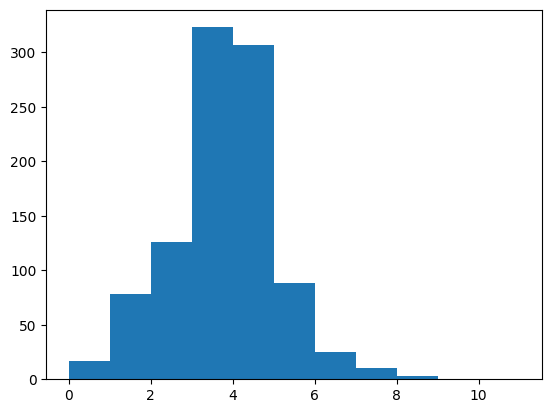

In [50]:
plt.hist(df['ocr_num_detected_leads'], bins = list(range(12)))
plt.show()

In [56]:
df.group_by('mm_mv').len()

mm_mv,len
f64,u32
10.0,977


In [57]:
df.group_by('mm_s').len()

mm_s,len
f64,u32
25.0,977


## EDA the signal range

In [77]:
global_min = df.select(pl.col([f'ecg_{lead}_min' for lead in ALL_LEADS])).to_numpy().min()
global_max = df.filter(
    pl.col('id') != 2042290760
).select(pl.col([f'ecg_{lead}_max' for lead in ALL_LEADS])).to_numpy().max()
global_mean = df.select(pl.col([f'ecg_{lead}_mean' for lead in ALL_LEADS])).to_numpy().mean()
global_median = np.median(df.select(pl.col([f'ecg_{lead}_median' for lead in ALL_LEADS])).to_numpy())

print('GLOBAL MIN:', global_min)
print('GLOBAL_MAX:', global_max)
print('GLOBAL_MEAN:', global_mean)
print('GLOBAL_MEDIAN:', global_median)

for lead in ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']:
    lead_min = df[f'ecg_{lead}_min'].min()
    lead_max = df[f'ecg_{lead}_max'].max()
    lead_mean = df[f'ecg_{lead}_mean'].mean()
    lead_median = df[f'ecg_{lead}_median'].median()
    print(f'lead={lead} min={lead_min} max={lead_max} range={lead_max - lead_min} mean={lead_mean} median={lead_median}')

GLOBAL MIN: -6.136
GLOBAL_MAX: 7.1
GLOBAL_MEAN: -0.6337843739338109
GLOBAL_MEDIAN: -0.014
lead=I min=-2.345 max=4.98 range=7.325000000000001 mean=-0.2464083930399181 median=-0.025
lead=II min=-2.26 max=7.1 range=9.36 mean=-0.39131729785056296 median=-0.021
lead=III min=-3.142 max=4.695 range=7.837 mean=-0.5579969293756397 median=0.004
lead=aVR min=-6.136 max=1.423 range=7.559 mean=-0.7357727737973389 median=0.025
lead=aVL min=-1.996 max=2.576 range=4.572 mean=-0.2586509723643808 median=-0.015
lead=aVF min=-2.468 max=4.513 range=6.981 mean=-0.3579825997952917 median=-0.005
lead=V1 min=-5.376 max=2.285 range=7.6610000000000005 mean=-0.9685731832139202 median=0.02
lead=V2 min=-5.146 max=2.778 range=7.9239999999999995 mean=-1.3751084953940638 median=-0.006
lead=V3 min=-4.753 max=4.916 range=9.669 mean=-1.1791044012282499 median=-0.029
lead=V4 min=-4.612 max=5.755 range=10.367 mean=-0.7907963152507678 median=-0.039
lead=V5 min=-4.199 max=5.178 range=9.376999999999999 mean=-0.443829068577277

In [62]:
df.filter(pl.col('ecg_V6_max') > 4)

id,fs,sig_len,height_0001,height_0003,height_0004,height_0005,height_0006,height_0009,height_0010,height_0011,height_0012,width_0001,width_0003,width_0004,width_0005,width_0006,width_0009,width_0010,width_0011,width_0012,sig_stat,ecg_I_min,ecg_I_max,ecg_I_mean,ecg_I_std,ecg_I_median,ecg_II_min,ecg_II_max,ecg_II_mean,ecg_II_std,ecg_II_median,ecg_III_min,ecg_III_max,ecg_III_mean,ecg_III_std,ecg_III_median,…,ecg_aVF_std,ecg_aVF_median,ecg_V1_min,ecg_V1_max,ecg_V1_mean,ecg_V1_std,ecg_V1_median,ecg_V2_min,ecg_V2_max,ecg_V2_mean,ecg_V2_std,ecg_V2_median,ecg_V3_min,ecg_V3_max,ecg_V3_mean,ecg_V3_std,ecg_V3_median,ecg_V4_min,ecg_V4_max,ecg_V4_mean,ecg_V4_std,ecg_V4_median,ecg_V5_min,ecg_V5_max,ecg_V5_mean,ecg_V5_std,ecg_V5_median,ecg_V6_min,ecg_V6_max,ecg_V6_mean,ecg_V6_std,ecg_V6_median,ocr_text,ocr_num_detected_leads,ocr_detected_leads,mm_s,mm_mv
i64,i64,i64,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i32,str,f64,f64
2042290760,1000,10000,1700,1652,1652,3024,4000,3024,3024,1652,1652,2200,2134,2132,4032,3000,4032,4032,2140,2142,"""{'I': {'min': -0.27, 'max': 0.…",-0.27,0.677,-0.27,0.119281,-0.02,-0.558,0.454,-0.558,0.124914,-0.01,-1.07,0.386,-1.07,0.178041,0.025,…,0.127009,0.007,-0.452,0.307,-0.452,0.09386,0.028,-0.788,0.46,-0.788,0.125917,0.009,-1.472,0.923,-1.472,0.270139,0.006,-0.907,1.54,-0.907,0.261284,-0.039,-0.384,1.109,-0.384,0.175013,-0.045,-2.457,32.117,-2.457,6.035865,-0.029,"""['aVL', '/', '1', '-', '二', '1…",2,"""['aVL', 'V6']""",25.0,10.0
4208757201,512,5120,1700,1652,1652,3024,3000,3024,3024,1652,1652,2200,2128,2130,4032,4000,4032,4032,2124,2124,"""{'I': {'min': -0.278, 'max': 1…",-0.278,1.127,-0.278,0.215545,-0.06,-0.798,0.592,-0.798,0.15503,0.0,-1.708,0.34,-1.708,0.276788,0.056,…,0.212265,0.014,-1.907,0.355,-1.907,0.350006,0.095,-2.871,0.698,-2.871,0.55031,0.098,-4.087,0.8,-4.087,0.717834,-0.058,-3.259,0.792,-3.259,0.585452,0.043,-0.729,3.819,-0.729,0.75911,-0.05,-0.624,4.224,-0.624,0.74508,-0.027,"""['i', '−', '2', '广', '+', '1',…",2,"""['V3', 'V6']""",25.0,10.0


In [81]:
def show_sid(*sids, idx = 1):
    for sid in sids:
        img_path = os.path.join(IMG_DIR, str(sid), f'{sid}-{idx:04d}.png')
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        print(f'---------{sid} {img.shape}--------')
        plt.imshow(img)
        plt.show()

---------2042290760 (1700, 2200, 3)--------


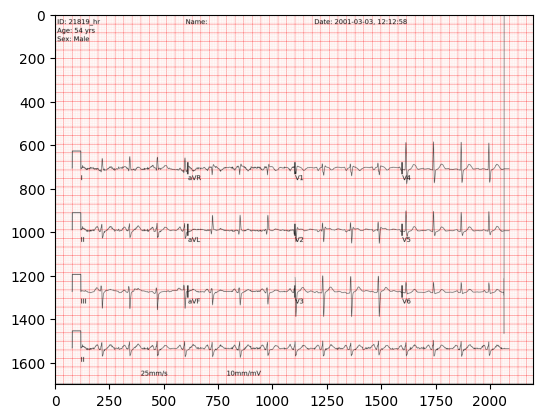

---------4208757201 (1700, 2200, 3)--------


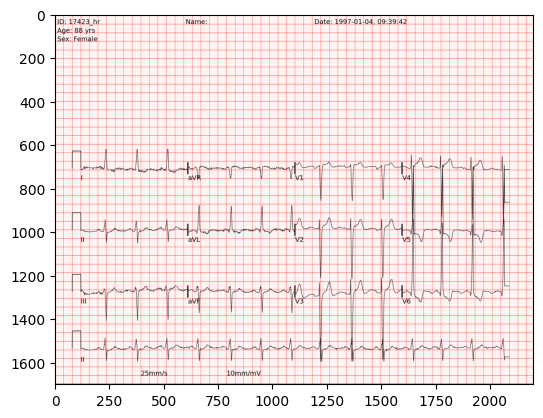

In [82]:
show_sid(2042290760, 4208757201)

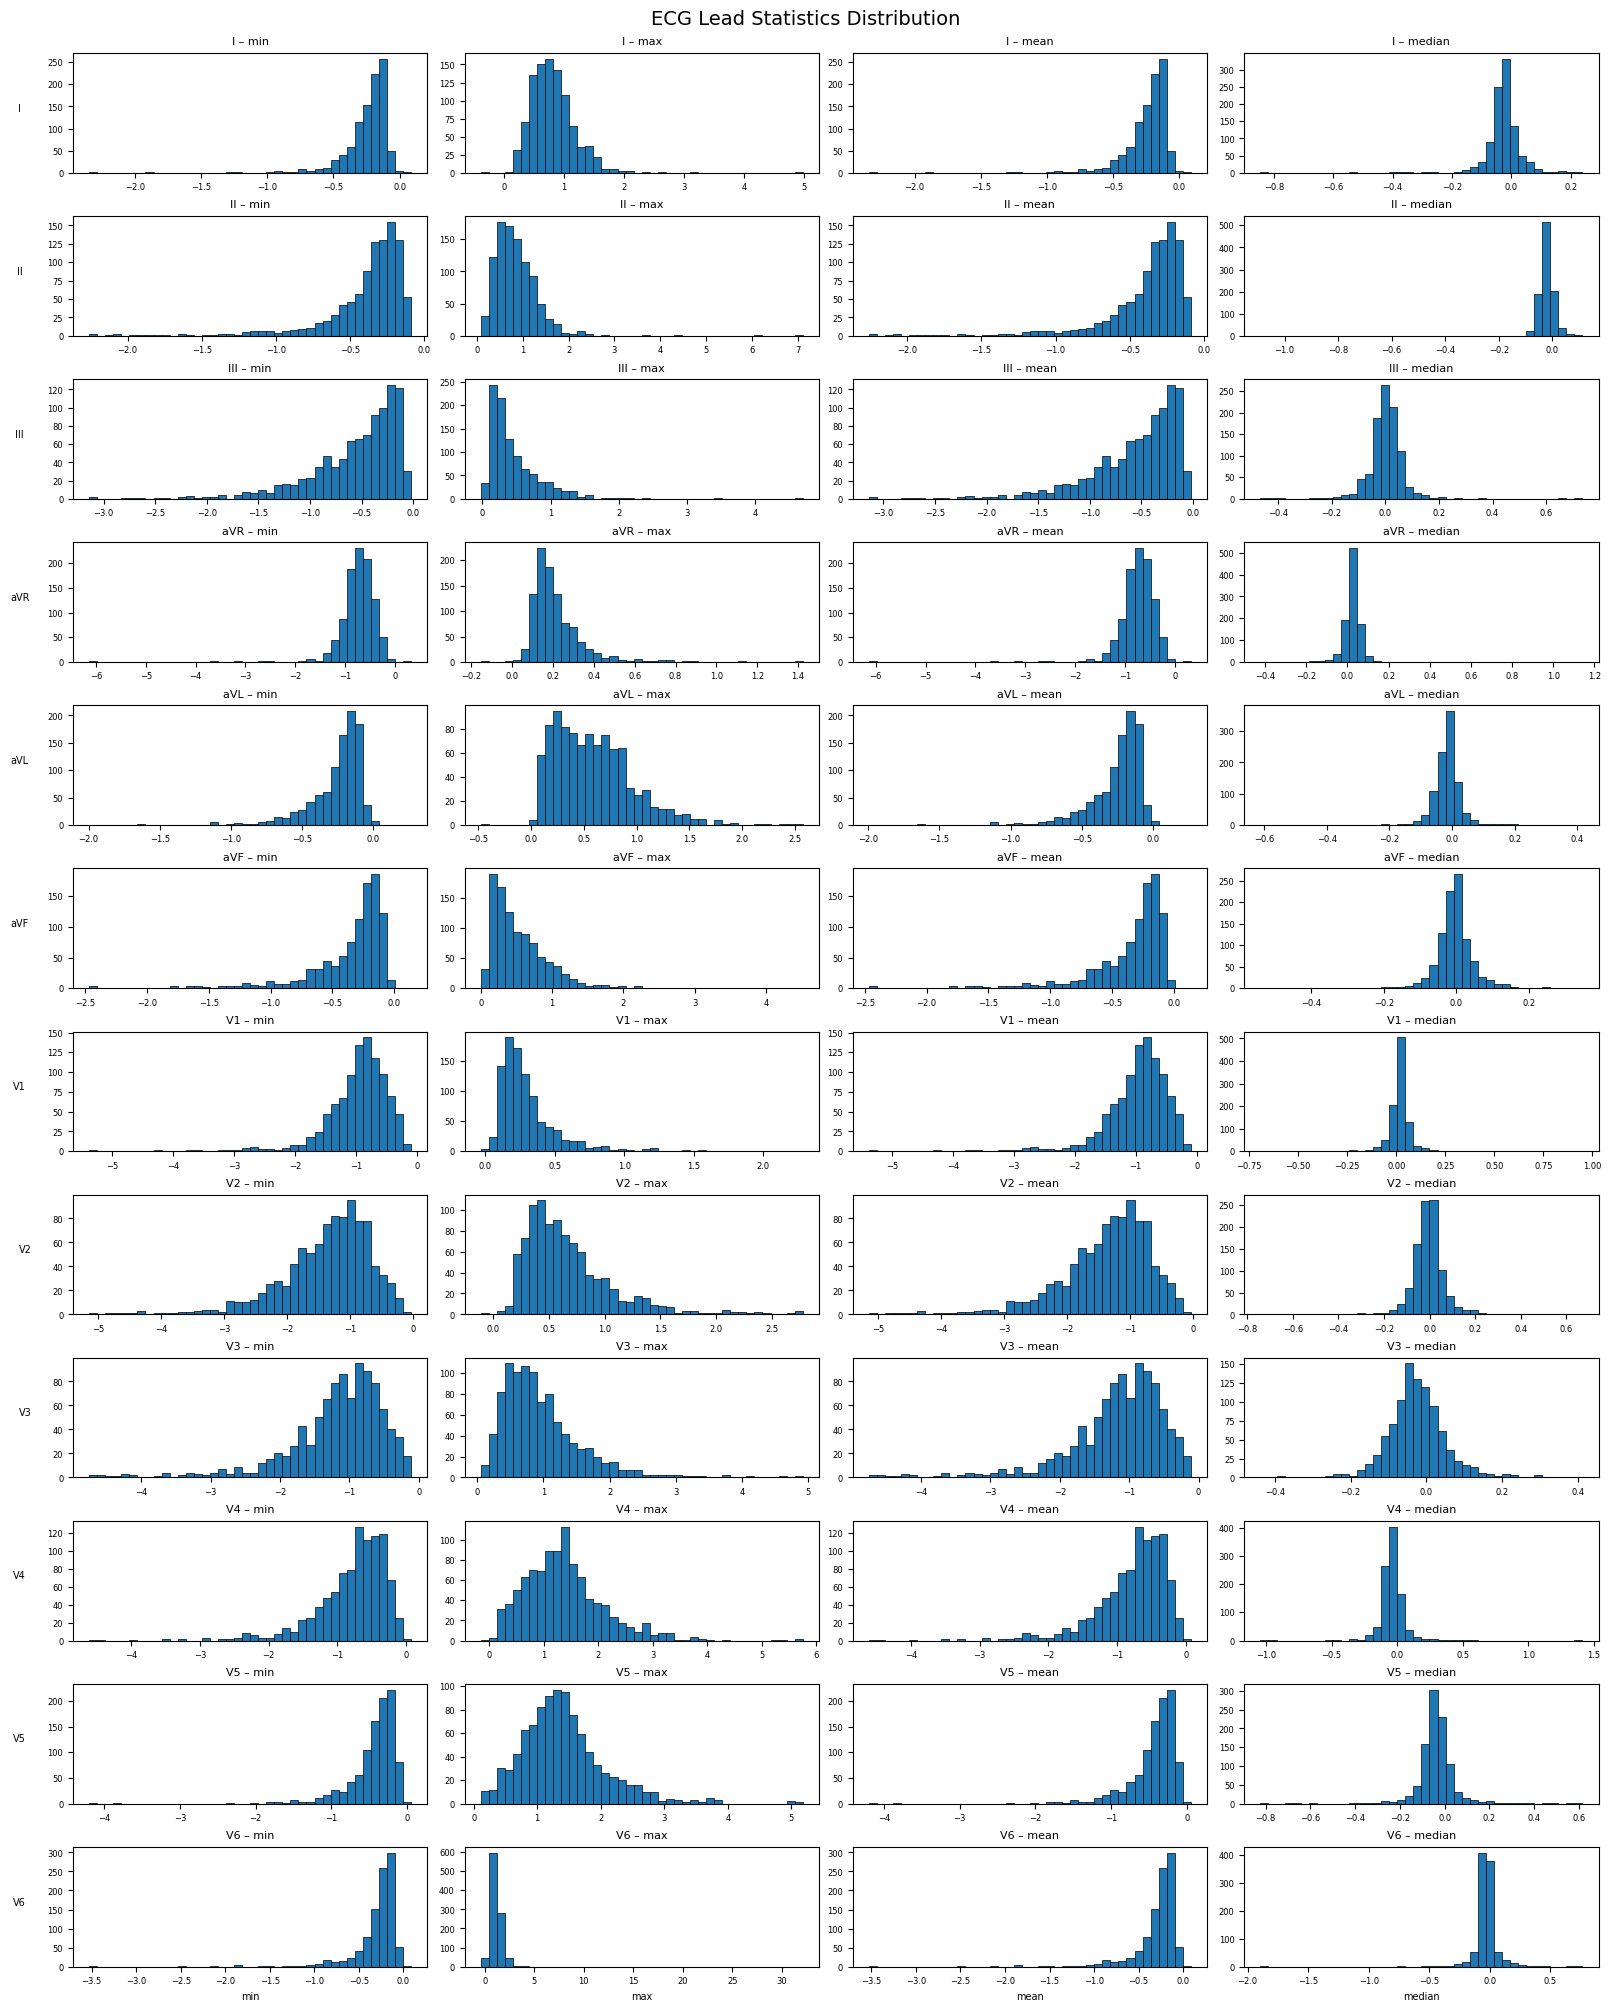

In [76]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

def plot_ecg_stats_grid(df: pl.DataFrame):
    """
    Display a 12x4 grid of histograms for ECG lead statistics.
    Each column = statistic (min, max, mean, median)
    Each row = ECG lead (I, II, III, aVR, aVL, aVF, V1–V6)
    """
    leads = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']
    stats = ['min','max','mean','median']

    fig, axes = plt.subplots(
        nrows=len(leads),
        ncols=len(stats),
        figsize=(16, 20),
        constrained_layout=True
    )

    for i, lead in enumerate(leads):
        for j, stat in enumerate(stats):
            ax = axes[i, j]
            col = f"ecg_{lead}_{stat}"

            if col not in df.columns:
                ax.set_visible(False)
                continue

            values = df[col].to_numpy()
            ax.hist(values, bins=40, edgecolor='black', linewidth=0.5)

            ax.set_title(f"{lead} – {stat}", fontsize=8)
            ax.tick_params(labelsize=6)

            # Label bottom row and left column for clarity
            if i == len(leads) - 1:
                ax.set_xlabel(stat, fontsize=7)
            if j == 0:
                ax.set_ylabel(lead, fontsize=7, rotation=0, labelpad=20)

    fig.suptitle("ECG Lead Statistics Distribution", fontsize=14)
    plt.show()



plot_ecg_stats_grid(df)

suitable range: (-6.1, 7.1) -> (-8, 8)

In [79]:
df.group_by('fs').first().sort('fs')['id'].to_list()

[19030958, 82847757, 7663343, 19585145, 10140238, 36494663]

---------19030958 (1700, 2200, 3)--------


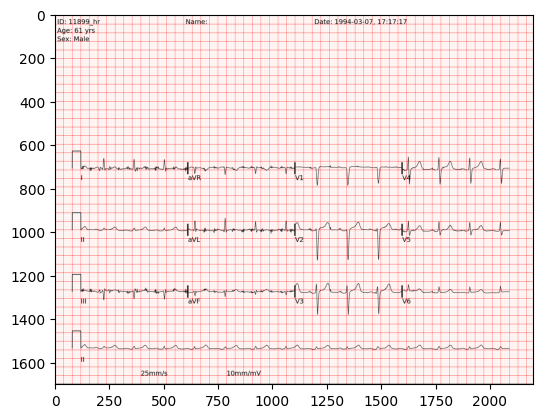

---------82847757 (1700, 2200, 3)--------


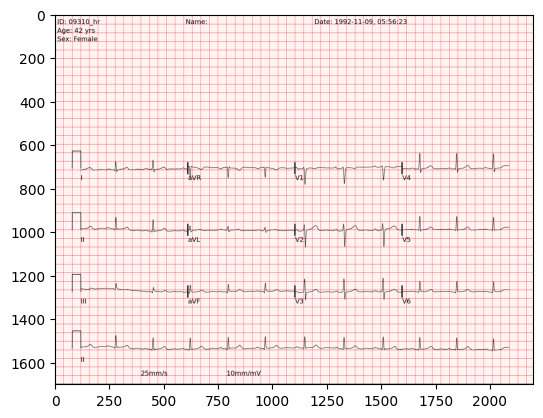

---------7663343 (1700, 2200, 3)--------


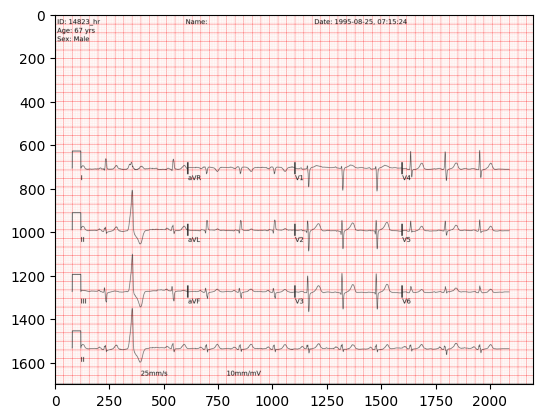

---------19585145 (1700, 2200, 3)--------


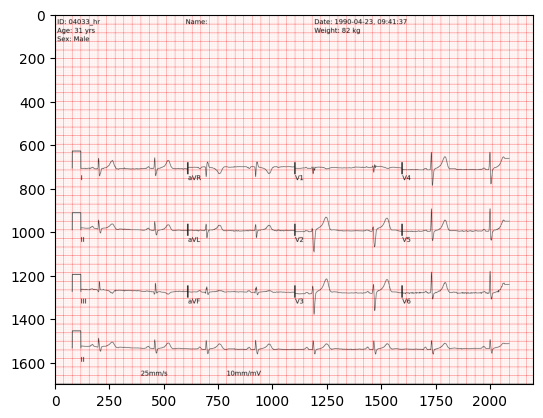

---------10140238 (1700, 2200, 3)--------


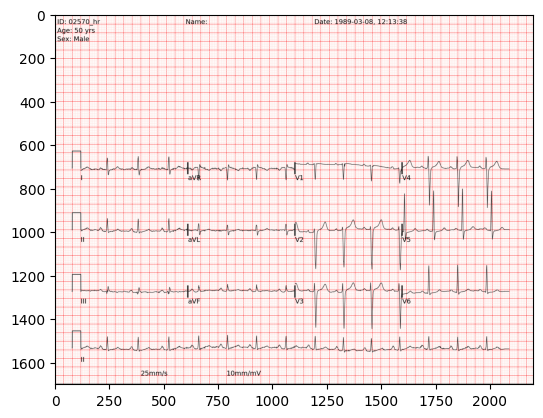

---------36494663 (1700, 2200, 3)--------


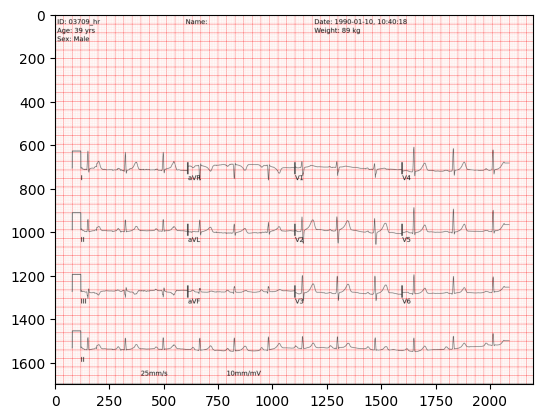

In [83]:
show_sid(19030958, 82847757, 7663343, 19585145, 10140238, 36494663)

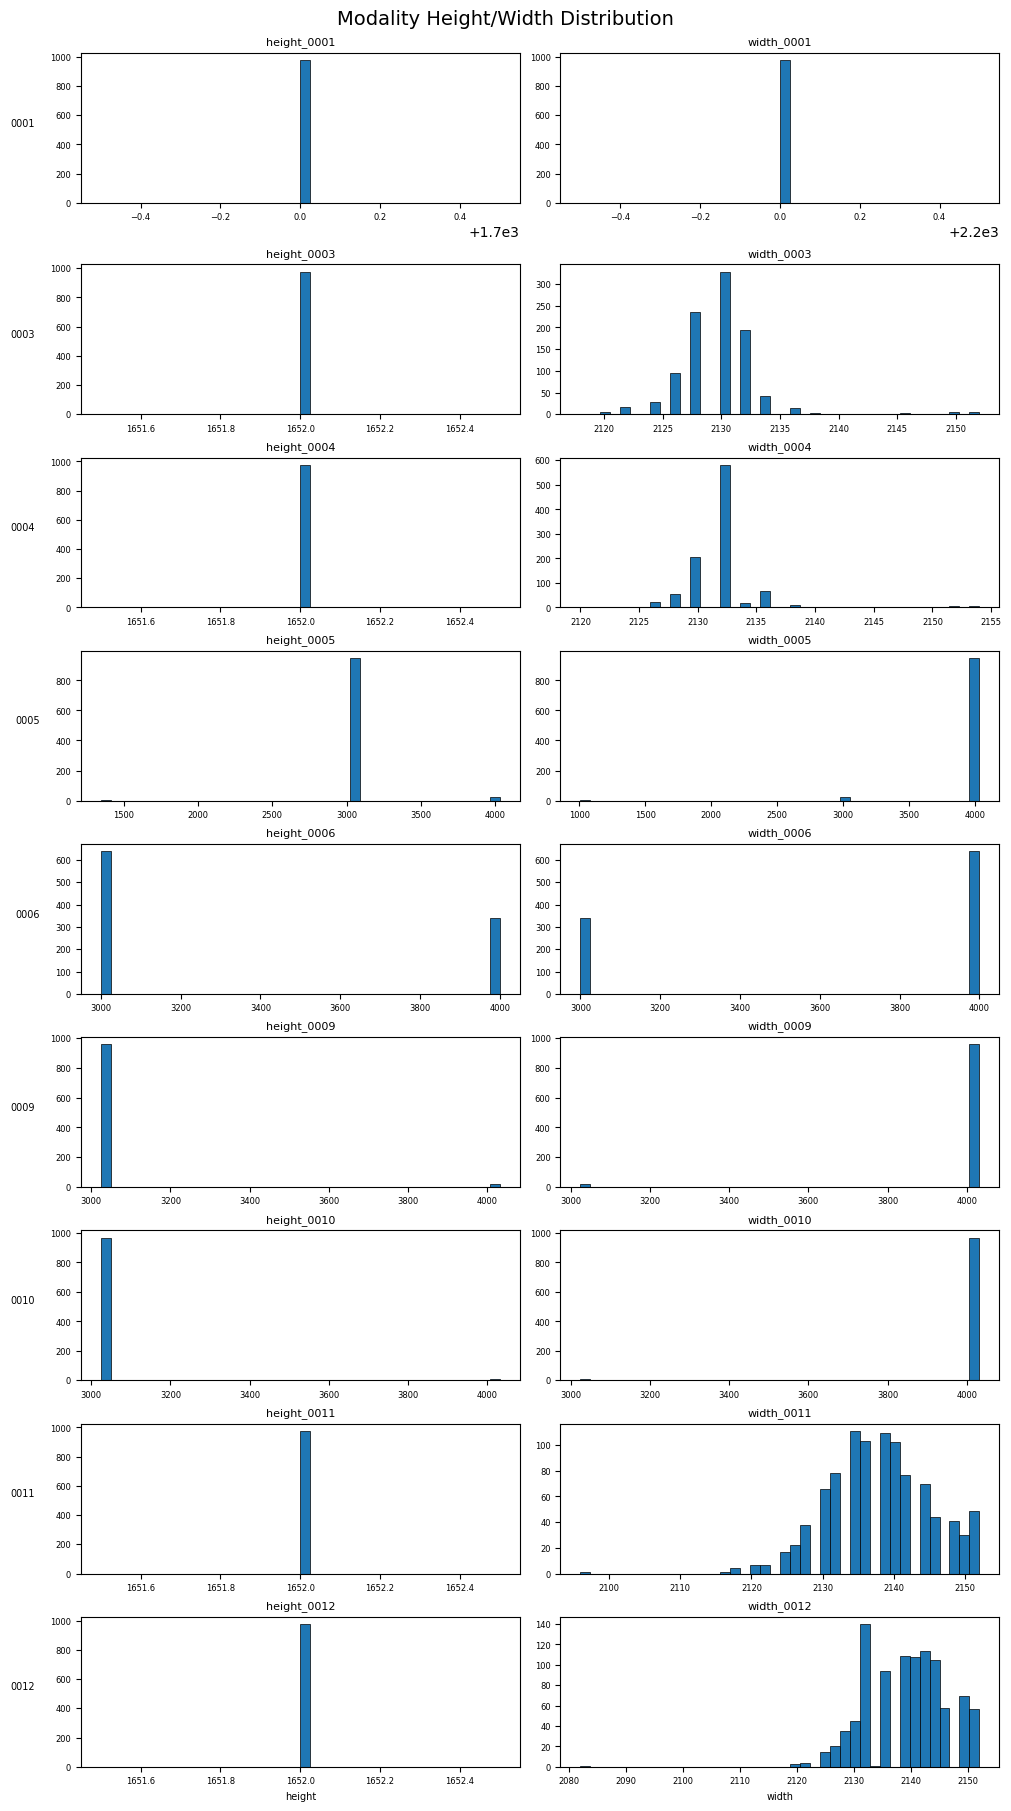

In [86]:
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

def plot_img_shape_grid(df: pl.DataFrame):
    """
    Display histograms for image shape statistics.
    Two columns: 'height' and 'width'.
    Each column contains histograms for all idxs stacked vertically.
    """
    prefixes = ['height', 'width']
    idxs = [1, 3, 4, 5, 6, 9, 10, 11, 12]

    fig, axes = plt.subplots(
        nrows=len(idxs),
        ncols=len(prefixes),
        figsize=(10, 18),
        constrained_layout=True
    )

    for i, idx in enumerate(idxs):
        for j, prefix in enumerate(prefixes):
            ax = axes[i, j]
            col = f"{prefix}_{idx:04d}"

            if col not in df.columns:
                ax.set_visible(False)
                continue

            values = df[col].to_numpy()
            ax.hist(values, bins=40, edgecolor='black', linewidth=0.5)
            ax.set_title(f"{prefix}_{idx:04d}", fontsize=8)
            ax.tick_params(labelsize=6)

            # Label axes for clarity
            if i == len(idxs) - 1:
                ax.set_xlabel(prefix, fontsize=7)
            if j == 0:
                ax.set_ylabel(f"{idx:04d}", fontsize=7, rotation=0, labelpad=20)

    fig.suptitle("Modality Height/Width Distribution", fontsize=14)
    plt.show()


plot_img_shape_grid(df)

## The whole signal range

In [37]:
all_signals = {}

for row_idx, row in tqdm(enumerate(df.iter_rows(named = True)), total = len(df)):
    sid = row['id']
    sid_dir = os.path.join(IMG_DIR, str(sid))
    names = sorted(os.listdir(sid_dir))
    assert len(names) == 10
    ecg_df = pl.scan_csv(os.path.join(sid_dir, f'{sid}.csv')).select(pl.col('*').cast(pl.Float64)).collect()
    if row_idx == 0:
        display(ecg_df)
    signal = ecg_df.to_numpy()
    null_mask = ~np.isnan(signal)
    lead_segments = {}
    sig_len = len(ecg_df)
    assert sig_len == row['sig_len']
    sid_sig_stats = {}
    _len = None
    for lead_idx, lead_name in enumerate(ecg_df.columns):
        assert lead_name in LEAD_TO_SIG_LEN
        idx = null_mask[:, lead_idx].nonzero()[0]
        first = int(idx[0]) if len(idx) > 0 else None
        last = int(idx[-1]) if len(idx) > 0 else None
        expect_start = int(LEAD_TO_SIG_LEN[lead_name][0] * sig_len)
        expect_end = int(LEAD_TO_SIG_LEN[lead_name][1] * sig_len - 1)
        assert first == expect_start and last == expect_end
        lead_segments[lead_name] = (first, last)

        lead_sig = signal[first:last+1, lead_idx]
        if _len is None:
            _len = len(lead_sig)
        assert len(lead_sig) == _len or (len(lead_sig) - 4 * _len) <= 2, f'{_len} {len(lead_sig)} {first} {last} {len(ecg_df)}'

        all_signals.setdefault(lead_name, []).extend(lead_sig.tolist())

  0%|                               | 0/977 [00:00<?, ?it/s]

I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.04,0.1,0.06,null,null,null,null,null,null,null,null,null
0.04,0.1,0.06,null,null,null,null,null,null,null,null,null
0.04,0.1,0.06,null,null,null,null,null,null,null,null,null
0.04,0.1,0.06,null,null,null,null,null,null,null,null,null
0.04,0.1,0.06,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…
null,-0.04,null,null,null,null,null,null,null,-0.065,-0.055,-0.025
null,-0.04,null,null,null,null,null,null,null,-0.065,-0.055,-0.025
null,-0.04,null,null,null,null,null,null,null,-0.065,-0.055,-0.025


100%|████████████████████| 977/977 [00:03<00:00, 295.89it/s]




------------- I ------------
length: 1441129
	 min --> -2.345
	 max --> 4.98
	 mean --> -2.345
	 median --> -0.023
	 std --> 0.15844240573060359
	 pct_0.1 --> -0.668
	 pct_0.01 --> -1.0946616
	 pct_1 --> -0.325
	 pct_5 --> -0.159
	 pct_95 --> 0.217
	 pct_99 --> 0.702
	 pct_99.9 --> 1.256
	 pct_99.99 --> 1.6537743999995291
	 range_0.01 --> [-1.0946616, 1.6537743999995291, 2.748435999999529]
	 range_0.1 --> [-0.668, 1.256, 1.924]
	 range_1 --> [-0.325, 0.702, 1.027]


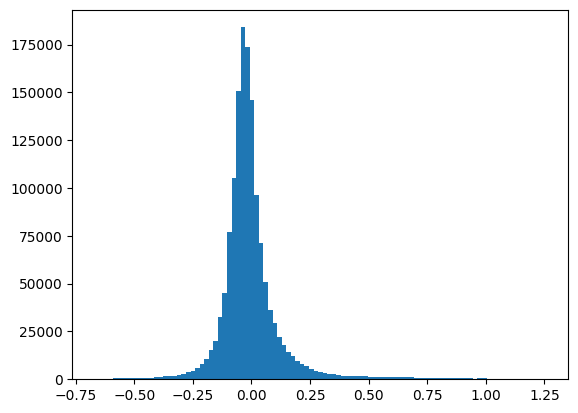



------------- II ------------
length: 5764840
	 min --> -2.26
	 max --> 7.1
	 mean --> -2.26
	 median --> -0.02
	 std --> 0.16315326905929664
	 pct_0.1 --> -1.005
	 pct_0.01 --> -1.5075161
	 pct_1 --> -0.366
	 pct_5 --> -0.169
	 pct_95 --> 0.221
	 pct_99 --> 0.625
	 pct_99.9 --> 1.256
	 pct_99.99 --> 1.941
	 range_0.01 --> [-1.5075161, 1.941, 3.4485161]
	 range_0.1 --> [-1.005, 1.256, 2.261]
	 range_1 --> [-0.366, 0.625, 0.991]


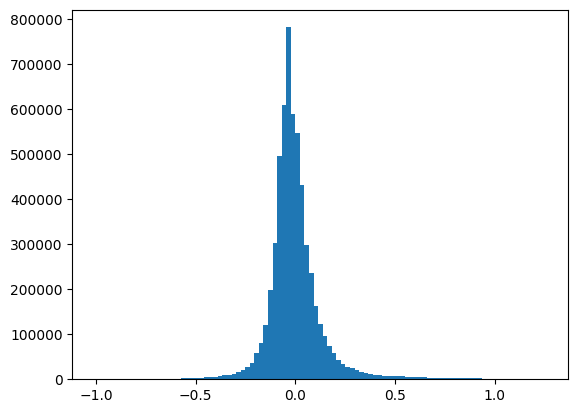



------------- III ------------
length: 1441129
	 min --> -3.142
	 max --> 4.695
	 mean --> -3.142
	 median --> 0.004
	 std --> 0.17291419466678148
	 pct_0.1 --> -1.411
	 pct_0.01 --> -2.5917744000000003
	 pct_1 --> -0.598
	 pct_5 --> -0.2
	 pct_95 --> 0.176
	 pct_99 --> 0.51
	 pct_99.9 --> 1.032
	 pct_99.99 --> 1.9320975999981165
	 range_0.01 --> [-2.5917744000000003, 1.9320975999981165, 4.523871999998117]
	 range_0.1 --> [-1.411, 1.032, 2.443]
	 range_1 --> [-0.598, 0.51, 1.108]


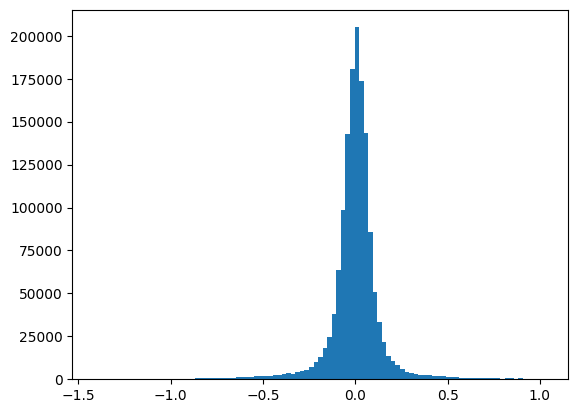



------------- aVR ------------
length: 1441291
	 min --> -6.136
	 max --> 1.423
	 mean --> -6.136
	 median --> 0.023
	 std --> 0.13436398575443892
	 pct_0.1 --> -1.047
	 pct_0.01 --> -1.439871
	 pct_1 --> -0.61
	 pct_5 --> -0.19
	 pct_95 --> 0.126
	 pct_99 --> 0.216
	 pct_99.9 --> 0.434
	 pct_99.99 --> 1.22787099999981
	 range_0.01 --> [-1.439871, 1.22787099999981, 2.66774199999981]
	 range_0.1 --> [-1.047, 0.434, 1.4809999999999999]
	 range_1 --> [-0.61, 0.216, 0.826]


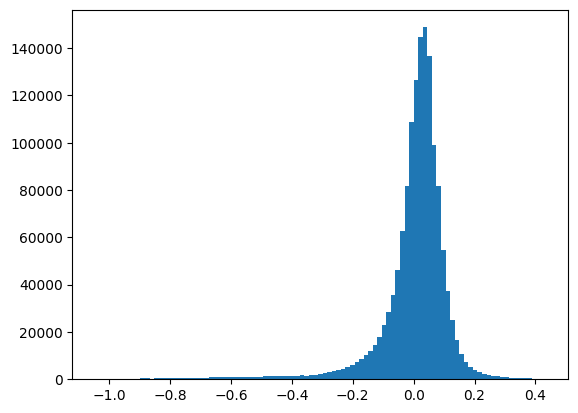



------------- aVL ------------
length: 1441291
	 min --> -1.996
	 max --> 2.576
	 mean --> -1.996
	 median --> -0.015
	 std --> 0.1331390844632857
	 pct_0.1 --> -0.616
	 pct_0.01 --> -0.9808709999999999
	 pct_1 --> -0.282
	 pct_5 --> -0.127
	 pct_95 --> 0.15
	 pct_99 --> 0.582
	 pct_99.9 --> 1.1837100000001957
	 pct_99.99 --> 2.027
	 range_0.01 --> [-0.9808709999999999, 2.027, 3.007871]
	 range_0.1 --> [-0.616, 1.1837100000001957, 1.7997100000001955]
	 range_1 --> [-0.282, 0.582, 0.8639999999999999]


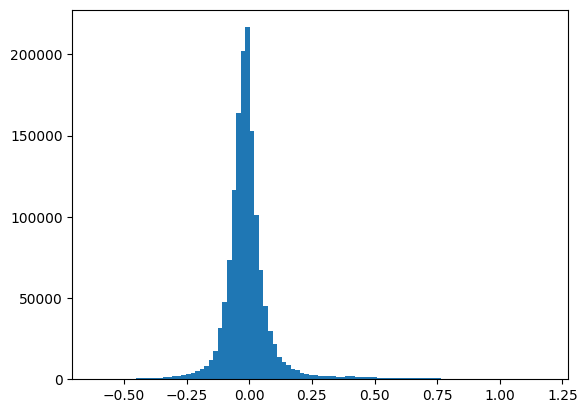



------------- aVF ------------
length: 1441291
	 min --> -2.468
	 max --> 4.513
	 mean --> -2.468
	 median --> -0.003
	 std --> 0.13859749405855143
	 pct_0.1 --> -1.088
	 pct_0.01 --> -1.902742
	 pct_1 --> -0.403
	 pct_5 --> -0.14
	 pct_95 --> 0.169
	 pct_99 --> 0.439
	 pct_99.9 --> 1.018
	 pct_99.99 --> 1.65587099999981
	 range_0.01 --> [-1.902742, 1.65587099999981, 3.55861299999981]
	 range_0.1 --> [-1.088, 1.018, 2.106]
	 range_1 --> [-0.403, 0.439, 0.8420000000000001]


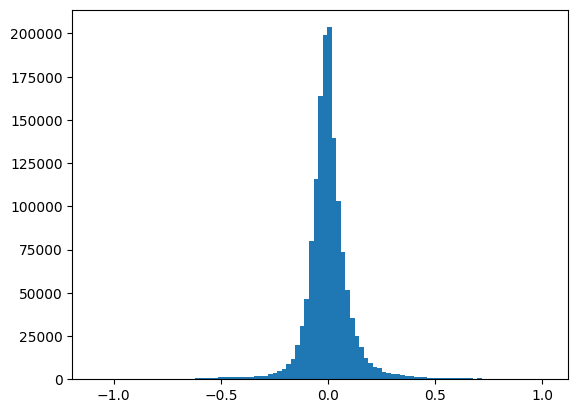



------------- V1 ------------
length: 1441129
	 min --> -5.376
	 max --> 2.285
	 mean --> -5.376
	 median --> 0.02
	 std --> 0.21703646125873177
	 pct_0.1 --> -2.051
	 pct_0.01 --> -2.9885488
	 pct_1 --> -0.95
	 pct_5 --> -0.288
	 pct_95 --> 0.19
	 pct_99 --> 0.424
	 pct_99.9 --> 0.919
	 pct_99.99 --> 1.2775487999990582
	 range_0.01 --> [-2.9885488, 1.2775487999990582, 4.266097599999058]
	 range_0.1 --> [-2.051, 0.919, 2.97]
	 range_1 --> [-0.95, 0.424, 1.3739999999999999]


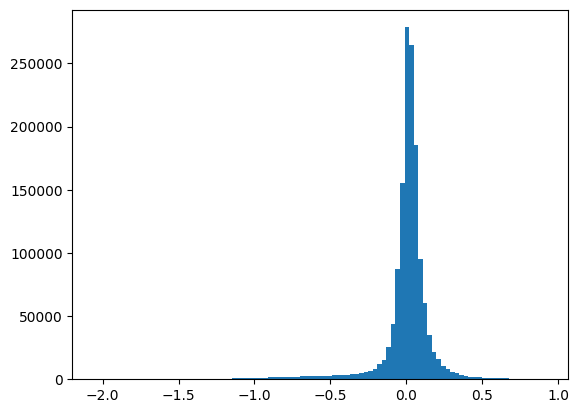



------------- V2 ------------
length: 1441129
	 min --> -5.146
	 max --> 2.778
	 mean --> -5.146
	 median --> 0.0
	 std --> 0.32184396935754417
	 pct_0.1 --> -2.873872
	 pct_0.01 --> -4.2548872
	 pct_1 --> -1.352
	 pct_5 --> -0.351
	 pct_95 --> 0.394
	 pct_99 --> 0.774
	 pct_99.9 --> 1.403
	 pct_99.99 --> 2.1048871999997645
	 range_0.01 --> [-4.2548872, 2.1048871999997645, 6.359774399999765]
	 range_0.1 --> [-2.873872, 1.403, 4.276872]
	 range_1 --> [-1.352, 0.774, 2.1260000000000003]


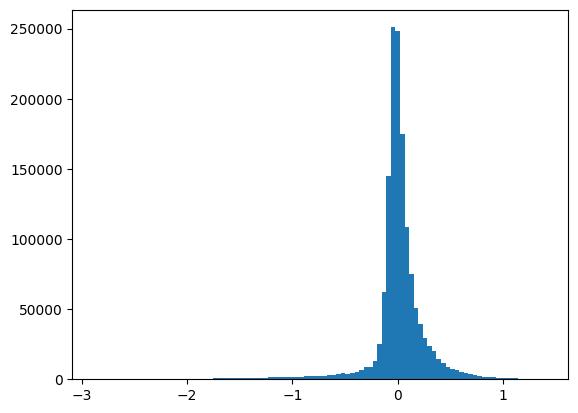



------------- V3 ------------
length: 1441129
	 min --> -4.753
	 max --> 4.916
	 mean --> -4.753
	 median --> -0.019
	 std --> 0.31705261108490146
	 pct_0.1 --> -2.911
	 pct_0.01 --> -4.2485488
	 pct_1 --> -1.135
	 pct_5 --> -0.294
	 pct_95 --> 0.42
	 pct_99 --> 0.904
	 pct_99.9 --> 1.749
	 pct_99.99 --> 2.8198871999997643
	 range_0.01 --> [-4.2485488, 2.8198871999997643, 7.068435999999764]
	 range_0.1 --> [-2.911, 1.749, 4.66]
	 range_1 --> [-1.135, 0.904, 2.039]


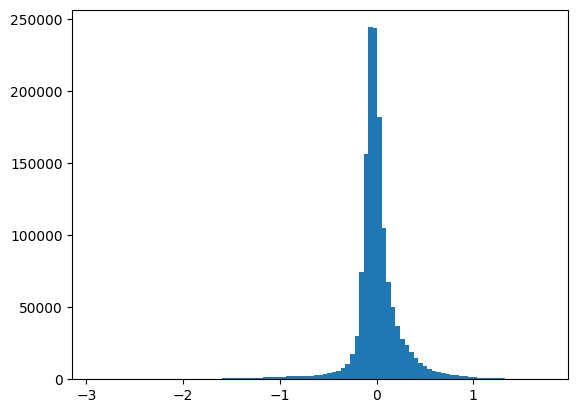



------------- V4 ------------
length: 1441291
	 min --> -4.612
	 max --> 5.755
	 mean --> -4.612
	 median --> -0.034
	 std --> 0.302849490188601
	 pct_0.1 --> -1.946
	 pct_0.01 --> -3.322
	 pct_1 --> -0.812
	 pct_5 --> -0.275
	 pct_95 --> 0.403
	 pct_99 --> 1.194
	 pct_99.9 --> 2.4217100000001954
	 pct_99.99 --> 3.567
	 range_0.01 --> [-3.322, 3.567, 6.889]
	 range_0.1 --> [-1.946, 2.4217100000001954, 4.367710000000195]
	 range_1 --> [-0.812, 1.194, 2.0060000000000002]


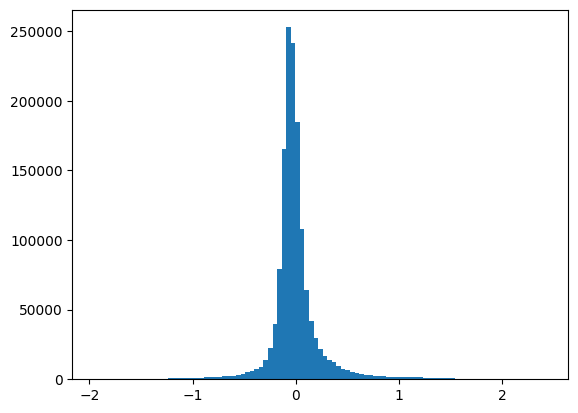



------------- V5 ------------
length: 1441291
	 min --> -4.199
	 max --> 5.178
	 mean --> -4.199
	 median --> -0.036
	 std --> 0.26363948577467117
	 pct_0.1 --> -1.228
	 pct_0.01 --> -2.5329679999999994
	 pct_1 --> -0.576
	 pct_5 --> -0.245
	 pct_95 --> 0.327
	 pct_99 --> 1.165
	 pct_99.9 --> 2.292
	 pct_99.99 --> 3.37935499999905
	 range_0.01 --> [-2.5329679999999994, 3.37935499999905, 5.912322999999049]
	 range_0.1 --> [-1.228, 2.292, 3.5199999999999996]
	 range_1 --> [-0.576, 1.165, 1.741]


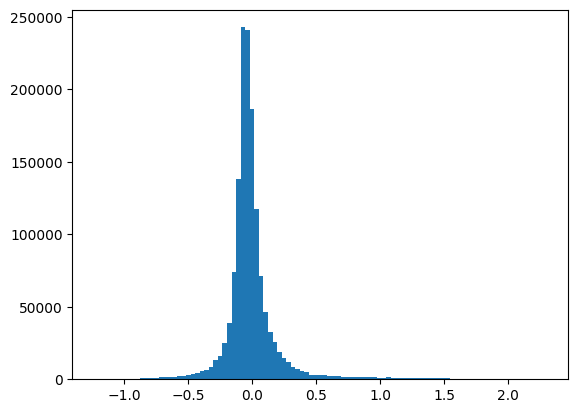



------------- V6 ------------
length: 1441291
	 min --> -3.528
	 max --> 32.117
	 mean --> -3.528
	 median --> -0.031
	 std --> 0.348807658047104
	 pct_0.1 --> -1.698
	 pct_0.01 --> -2.561871
	 pct_1 --> -0.497
	 pct_5 --> -0.218
	 pct_95 --> 0.302
	 pct_99 --> 1.005
	 pct_99.9 --> 1.812
	 pct_99.99 --> 3.64893599999696
	 range_0.01 --> [-2.561871, 3.64893599999696, 6.21080699999696]
	 range_0.1 --> [-1.698, 1.812, 3.51]
	 range_1 --> [-0.497, 1.005, 1.5019999999999998]


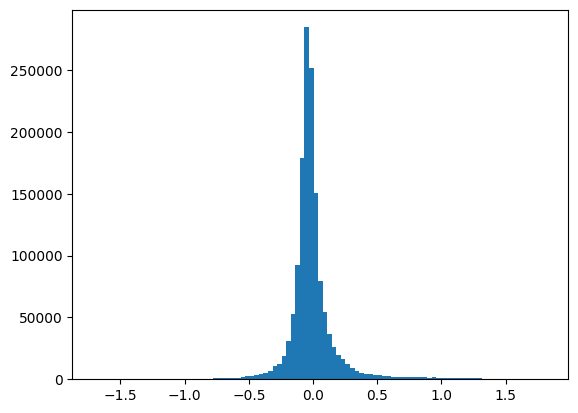

In [46]:
for k, v in all_signals.items():
    print(f'\n\n------------- {k} ------------')
    print('length:', len(v))
    sig_stats = {
            'min': np.min(v),
            'max': np.max(v),
            'mean': np.min(v),
            'median': np.median(v),
            'std': np.std(v),
            'pct_0.1': np.percentile(v, 0.1),
    }
    for p in [0.01, 0.1, 1, 5, 95, 99, 99.9, 99.99]:
        sig_stats[f'pct_{p}'] = np.percentile(v, p)
    sig_stats['range_0.01'] = [sig_stats['pct_0.01'], sig_stats['pct_99.99'], sig_stats['pct_99.99'] - sig_stats['pct_0.01']]
    sig_stats['range_0.1'] = [sig_stats['pct_0.1'], sig_stats['pct_99.9'], sig_stats['pct_99.9'] - sig_stats['pct_0.1']]
    sig_stats['range_1'] = [sig_stats['pct_1'], sig_stats['pct_99'], sig_stats['pct_99'] - sig_stats['pct_1']]
    for _k, _v in sig_stats.items():
        print('\t', _k, '-->', _v)
    plt.hist(v, bins = np.linspace(sig_stats['pct_0.1'], sig_stats['pct_99.9'], 100))
    plt.show()